## 1. Generate the synthetic movie

Same fixture as `tutorial2.ipynb` so results are directly comparable.

## 2. Helpers — Pearson, normalisation, neuron matching

`match_components_by_truth` pairs each true neuron with whichever extracted neuron has the highest spatial correlation, returning `(true_idx, est_idx, spatial_r)`. We use the same helper for both pipelines so the comparison is symmetric.

## 3. Run our CNMFe pipeline

In [5]:
# Iteration-equalised variant: same params but n_iter_main=1 to match CaImAn's
# hardcoded single-cycle structure. Isolates algorithm quality from iteration count.
params_1iter = CNMFeParams(
    sigma=3.0, min_corr=0.8, min_pnr=6.0,
    n_iter_main=1,
    n_iter_temporal=2, mc_n_iter=1,
    spatial_max_thr=0.1, merge_thr_corr=0.85, merge_thr_overlap=0.5,
    global_ar=False,  # per-neuron g estimated from each C_raw[k]
    n_jobs=-1,
)
t0 = time.time()
ours1 = CNMFe(params_1iter).fit(movie, do_motion_correction=False)
t_ours1 = time.time() - t0

A_ours1   = ours1.A
C_ours1   = ours1.C
YrA_ours1 = ours1.YrA
Cproj_ours1 = C_ours1 + YrA_ours1

print(f'\nours (1 iter): K = {A_ours1.shape[1]}   wall = {t_ours1:.2f}s')

Estimating noise...
Computing CORR and PNR images...
Running greedy CORR-PNR initialization...
  Found 10 initial components.
Fitting ring-model background (radius=10.5px)...
Refinement iteration 1/1...
  Pre-merging duplicate seeds...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).
Final temporal update...
Done. Extracted 10 neurons.

ours (1 iter): K = 10   wall = 110.21s


In [6]:
import caiman as cm
from caiman.source_extraction.cnmf import cnmf as cnmf_module
from caiman.source_extraction.cnmf import params as params_module

# --- Save the movie as a CaImAn-style memory-mapped file -------------------
mmap_dir = tempfile.mkdtemp()
mmap_base = os.path.join(mmap_dir, 'caiman_movie_')

# CaImAn expects (T, H, W) float32. Save and then load as memmap.
fname_mmap = cm.save_memmap([movie.astype(np.float32)],
                            base_name=mmap_base, order='C')

Yr, mmap_dims, mmap_T = cm.load_memmap(fname_mmap)
images = Yr.T.reshape((mmap_T,) + mmap_dims, order='F')   # (T, H, W) view
print(f'memmap: T={mmap_T}, dims={mmap_dims}, file={fname_mmap}')

memmap: T=6500, dims=(64, 64), file=C:\Users\Florian\caiman_data\temp\caiman_movie_d1_64_d2_64_d3_1_order_C_frames_6500.mmap


In [7]:
# --- Configure CaImAn for CNMF-E -------------------------------------------
# Parameters are matched 1:1 to our CNMFeParams where CaImAn exposes an equivalent.
# Structural differences (no configurable fix) are noted in the markdown table above.
gSig = (3, 3)                  # neuron half-size (px) — matches our sigma=3.0
gSiz = (4 * gSig[0] + 1,) * 2  # patch size in greedy init (CaImAn convention)

opts_dict = {
    'fnames':                     [fname_mmap],
    'fr':                         30,                  # fps
    'decay_time':                 0.4,                 # used only for quality metrics, not AR estimation
    'method_init':                'corr_pnr',          # CNMF-E init
    'K':                          None,                # uncapped — matches max_neurons=None
    'gSig':                       gSig,                # matches sigma=3.0
    'gSiz':                       gSiz,
    'merge_thr':                  0.85,                # temporal correlation threshold — matches merge_thr_corr=0.85
    'p':                          1,                   # AR(1) — matches ar_order=1
    'tsub':                       1,                   # no temporal subsampling
    'ssub':                       1,                   # no spatial subsampling
    'rf':                         None,                # no patches (movie is small)
    'stride':                     None,
    'only_init':                  False,
    'nb':                         0,                   # no global low-rank bg (CNMF-E uses ring)
    'nb_patch':                   0,
    'method_deconvolution':       'oasis',             # matches our deconvolution backend
    'low_rank_background':        None,
    'update_background_components': False,
    'min_corr':                   0.8,                 # matches min_corr=0.8
    'min_pnr':                    6.0,                 # matches min_pnr=6.0
    'normalize_init':             False,
    'center_psf':                 True,                # matches center_psf=True
    'ssub_B':                     1,                   # full-resolution ring bg — matches our compute_W (CaImAn default was 2)
    'ring_size_factor':           1.5,                 # matches ring_size_factor=1.5
    'thr_method':                 'max',               # peak-fraction thresholding — matches spatial_max_thr (CaImAn default was 'nrg')
    'maxthr':                     0.1,                 # zero pixels < 10% of peak — matches spatial_max_thr=0.1
    'del_duplicates':             True,                # remove duplicate seeds (like our pre-merge on iter 0)
    'border_pix':                 5,                   # matches border_px=5
}
opts = params_module.CNMFParams(params_dict=opts_dict)


In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


In [15]:
# cm.stop_server(
# )

In [16]:
matches_ours   = match_components_by_truth(A_ours,   A_true)
matches_ours1  = match_components_by_truth(A_ours1,  A_true)
matches_caiman = match_components_by_truth(A_caiman, A_true)

rs_A_ours   = np.array([m[2] for m in matches_ours])
rs_A_ours1  = np.array([m[2] for m in matches_ours1])
rs_A_caiman = np.array([m[2] for m in matches_caiman])

fp_ours   = A_ours.shape[1]   - (rs_A_ours   > 0.7).sum()
fp_ours1  = A_ours1.shape[1]  - (rs_A_ours1  > 0.7).sum()
fp_caiman = A_caiman.shape[1] - (rs_A_caiman > 0.7).sum()

print(f'                      ours(2)   ours(1)    caiman')
print(f'K extracted           {A_ours.shape[1]:6d}    {A_ours1.shape[1]:6d}    {A_caiman.shape[1]:6d}')
print(f'mean spatial r        {rs_A_ours.mean():6.3f}    {rs_A_ours1.mean():6.3f}    {rs_A_caiman.mean():6.3f}')
print(f'min  spatial r        {rs_A_ours.min():6.3f}    {rs_A_ours1.min():6.3f}    {rs_A_caiman.min():6.3f}')
print(f'recovered (>0.7)      {(rs_A_ours > 0.7).sum():4d}/{K}    {(rs_A_ours1 > 0.7).sum():4d}/{K}    {(rs_A_caiman > 0.7).sum():4d}/{K}')
print(f'unmatched FP          {fp_ours:6d}    {fp_ours1:6d}    {fp_caiman:6d}')
print()
print('Per-neuron spatial r:')
print(f'  true   ours(2)  ours(1)  caiman')
for k in range(K):
    print(f'   {k:2d}    {rs_A_ours[k]:.3f}    {rs_A_ours1[k]:.3f}    {rs_A_caiman[k]:.3f}')

                      ours(2)   ours(1)    caiman
K extracted               10        10        10
mean spatial r         0.979     0.981     0.634
min  spatial r         0.973     0.978     0.223
recovered (>0.7)        10/10      10/10       4/10
unmatched FP               0         0         6

Per-neuron spatial r:
  true   ours(2)  ours(1)  caiman
    0    0.981    0.981    0.223
    1    0.981    0.981    0.929
    2    0.979    0.978    0.666
    3    0.980    0.979    0.474
    4    0.980    0.981    0.585
    5    0.973    0.981    0.401
    6    0.979    0.981    0.904
    7    0.980    0.980    0.842
    8    0.981    0.985    0.717
    9    0.978    0.981    0.596


## 6. Temporal recovery — `C + YrA` vs `C_true`

For each true neuron we pick the matched extracted component (from §5) and compute the Pearson correlation between its noisy projected trace `C + YrA` and the true calcium trace.

We report two flavours per pipeline:
- `C` only — the OASIS-deconvolved trace
- `C + YrA` — the noisy projected trace (shape-faithful)

Both pipelines should give similar `C + YrA` correlations against truth — that's the test of whether each extraction localises the right pixels. The `C`-alone numbers will be lower because OASIS imposes the AR(1) shape constraint that subtly distorts spike timing.

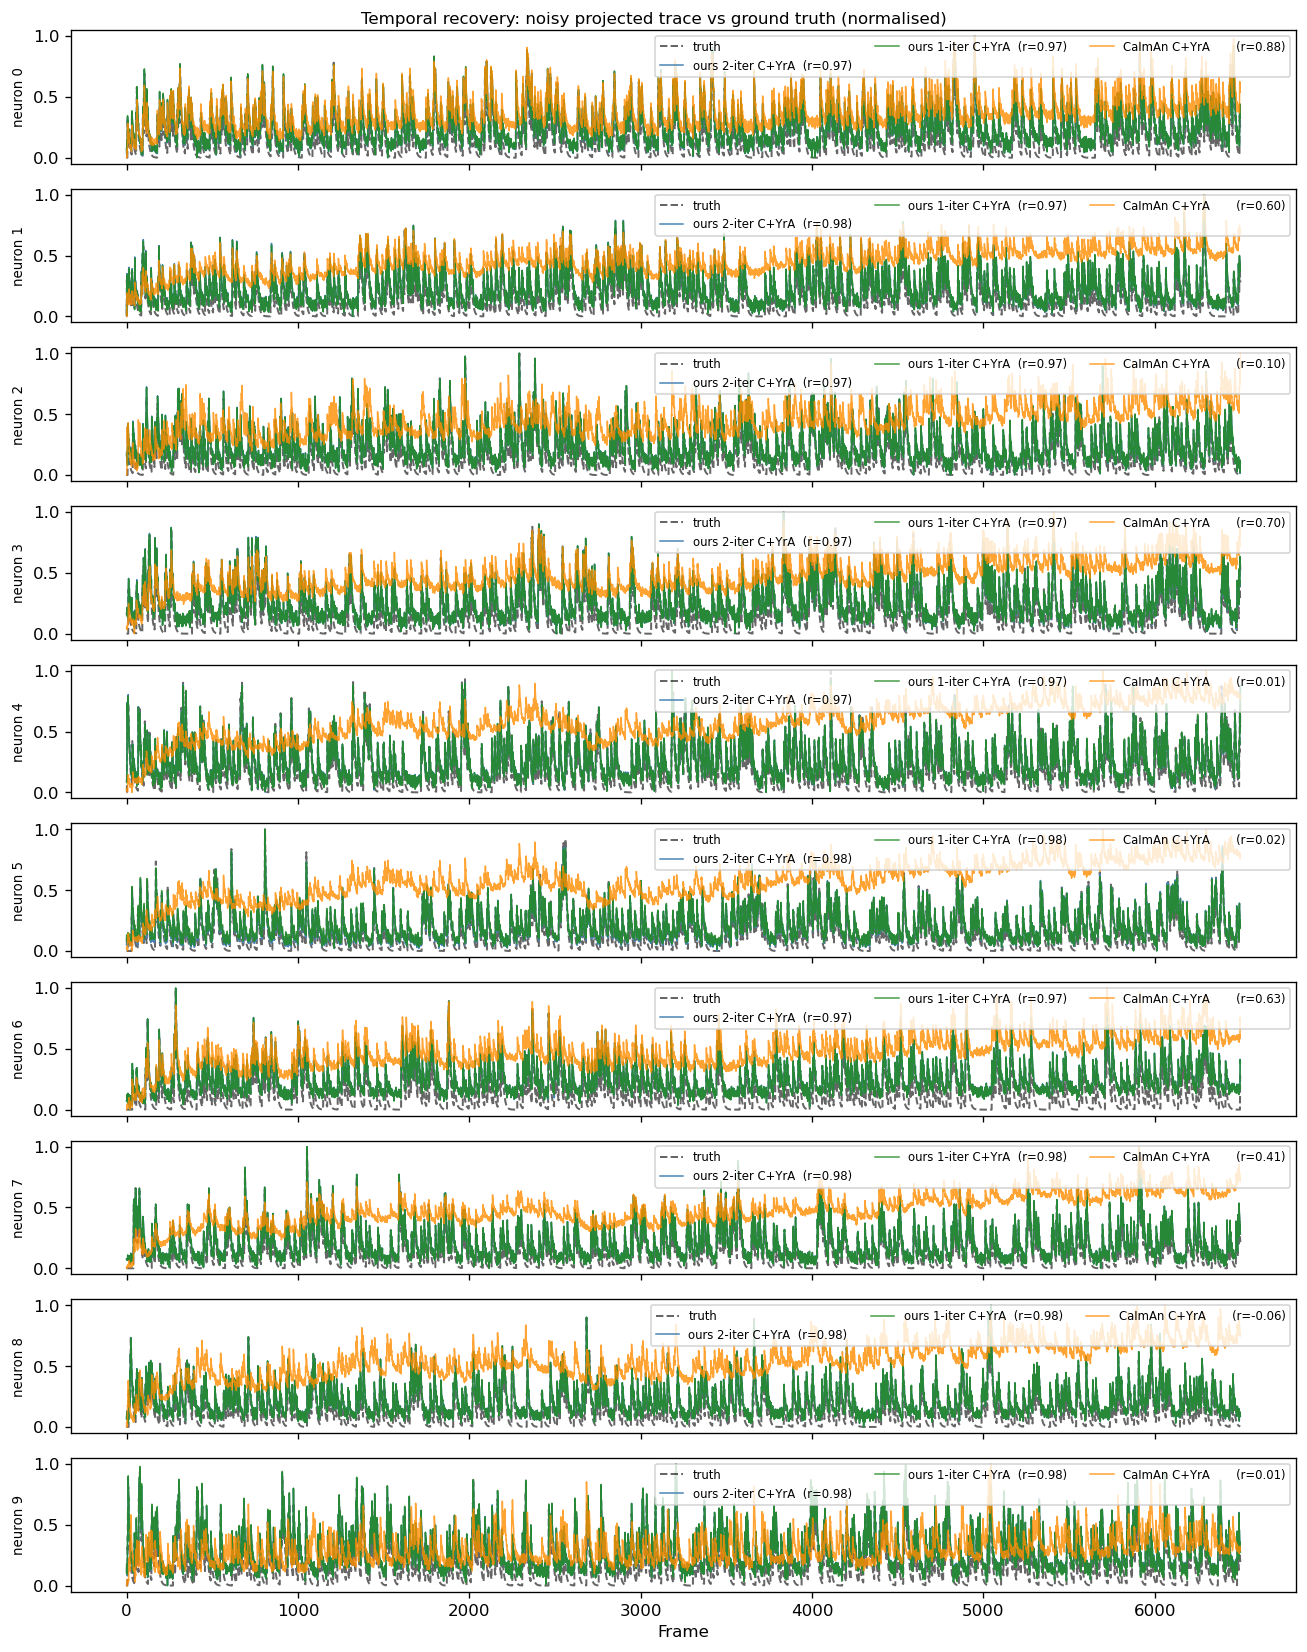

In [19]:
# --- Per-neuron trace comparison plot --------------------------------------
fig, axes = plt.subplots(K, 1, figsize=(11, 1.4 * K), sharex=True)
if K == 1: axes = [axes]
for ax, k in zip(axes, range(K)):
    _, ke_ours,   _ = matches_ours[k]
    _, ke_ours1,  _ = matches_ours1[k]
    _, ke_caiman, _ = matches_caiman[k]

    ax.plot(norm01(C_true[k]), lw=1.2, color='black', ls='--', alpha=0.6, label='truth')
    if ke_ours >= 0:
        ax.plot(norm01(Cproj_ours[ke_ours]),   lw=0.9, color='steelblue',
                label=f'ours 2-iter C+YrA  (r={pearson(Cproj_ours[ke_ours], C_true[k]):.2f})')
    if ke_ours1 >= 0:
        ax.plot(norm01(Cproj_ours1[ke_ours1]), lw=0.9, color='forestgreen', alpha=0.85,
                label=f'ours 1-iter C+YrA  (r={pearson(Cproj_ours1[ke_ours1], C_true[k]):.2f})')
    if ke_caiman >= 0:
        ax.plot(norm01(Cproj_caiman[ke_caiman]), lw=0.9, color='darkorange', alpha=0.8,
                label=f'CaImAn C+YrA       (r={pearson(Cproj_caiman[ke_caiman], C_true[k]):.2f})')
    ax.set_ylabel(f'neuron {k}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Temporal recovery: noisy projected trace vs ground truth (normalised)', fontsize=10)
plt.tight_layout(); plt.show()

In [20]:
print('=================================================================')
print(f'{"metric":<30} {"ours(2)":>9} {"ours(1)":>9} {"caiman":>9}')
print('=================================================================')
print(f'{"K extracted":<30} {A_ours.shape[1]:>9d} {A_ours1.shape[1]:>9d} {A_caiman.shape[1]:>9d}')
print(f'{"matched (>0.7 spatial r)":<30} '
      f'{(rs_A_ours > 0.7).sum():>9d} {(rs_A_ours1 > 0.7).sum():>9d} {(rs_A_caiman > 0.7).sum():>9d}')
print(f'{"unmatched (FP candidates)":<30} {fp_ours:>9d} {fp_ours1:>9d} {fp_caiman:>9d}')
print(f'{"mean spatial r":<30} {rs_A_ours.mean():>9.3f} {rs_A_ours1.mean():>9.3f} {rs_A_caiman.mean():>9.3f}')
print(f'{"mean temporal r (C only)":<30} '
      f'{rs_C_ours.mean():>9.3f} {rs_C_ours1.mean():>9.3f} {rs_C_caiman.mean():>9.3f}')
print(f'{"mean temporal r (C + YrA)":<30} '
      f'{rs_proj_ours.mean():>9.3f} {rs_proj_ours1.mean():>9.3f} {rs_proj_caiman.mean():>9.3f}')
print(f'{"wall time (s)":<30} {t_ours:>9.2f} {t_ours1:>9.2f} {t_caiman:>9.2f}')
print('=================================================================')

metric                           ours(2)   ours(1)    caiman
K extracted                           10        10        10
matched (>0.7 spatial r)              10        10         4
unmatched (FP candidates)              0         0         6
mean spatial r                     0.979     0.981     0.634
mean temporal r (C only)           0.615     0.578     0.344
mean temporal r (C + YrA)          0.974     0.974     0.331
wall time (s)                     141.09    110.21     78.81


In [25]:
from tests.miniscope_simulator import make_miniscope_movie

data_r = make_miniscope_movie(
    n_neurons=10, dims=(64, 64), T=6500,
    fps=20.0,
    bg_strength=4.0, bg_n_components=5,
    n_ghost_cells=6,
    vasculature=True,
    vignette_strength=0.4,
    photobleach_tau_factor=3.0,
    shot_noise=True, quantize_8bit=True,
    seed=1,
)

movie_r  = data_r['movie']        # (T, H, W) float32
A_true_r = data_r['A_true']       # (H*W, K) — true neurons only (no ghost cells)
C_true_r = data_r['C_true']       # (K, T)
g_true_r = data_r['g_true']       # (K,) per-neuron AR decay
K_r      = C_true_r.shape[0]

print(f'Realistic movie:    {movie_r.shape}')
print(f'True neurons:       {K_r}  (+ 6 ghost cells in background)')
print(f'Read noise std:     {data_r["sn_true"]:.3f}')
print(f'AR(1) decay range:  [{g_true_r.min():.3f}, {g_true_r.max():.3f}]  (vs fixed 0.9 in simple movie)')

Realistic movie:    (6500, 64, 64)
True neurons:       6  (+ 6 ghost cells in background)
Read noise std:     0.400
AR(1) decay range:  [0.898, 0.927]  (vs fixed 0.9 in simple movie)


In [27]:
# --- Run CaImAn on the realistic movie -------------------------------------
mmap_base_r = os.path.join(mmap_dir, 'caiman_movie_r_')
fname_mmap_r = cm.save_memmap([movie_r.astype(np.float32)],
                              base_name=mmap_base_r, order='C')
Yr_r, mmap_dims_r, mmap_T_r = cm.load_memmap(fname_mmap_r)
images_r = Yr_r.T.reshape((mmap_T_r,) + mmap_dims_r, order='F')

opts_dict_r = dict(opts_dict)   # copy aligned opts; override movie-specific fields
opts_dict_r.update({
    'fnames':   [fname_mmap_r],
    'min_pnr':  8.0,            # higher threshold for ghost rejection
})
opts_r = params_module.CNMFParams(params_dict=opts_dict_r)

# Shut down joblib's loky workers before CaImAn starts its cluster.
get_reusable_executor().shutdown(wait=True)

c_r, dview_r, n_proc_r = cm.cluster.setup_cluster(
    backend='multiprocessing', n_processes=1, single_thread=True
)
try:
    t0 = time.time()
    cnm_r = cnmf_module.CNMF(n_processes=1, dview=dview_r, Ain=None, params=opts_r)
    cnm_r.fit(images_r)
    t_caiman_r = time.time() - t0
finally:
    cm.cluster.stop_server(dview=dview_r)

A_caiman_r   = cnm_r.estimates.A
C_caiman_r   = np.asarray(cnm_r.estimates.C)
YrA_caiman_r = np.asarray(cnm_r.estimates.YrA) if cnm_r.estimates.YrA is not None else \
               np.zeros_like(C_caiman_r)
Cproj_caiman_r = C_caiman_r + YrA_caiman_r

print(f'caiman (realistic): K = {A_caiman_r.shape[1]}   wall = {t_caiman_r:.2f}s')

FileExistsError: [WinError 183] Eine Datei kann nicht erstellt werden, wenn sie bereits vorhanden ist: 'C:\\Users\\Florian\\caiman_data\\temp\\caiman_movie_r_d1_64_d2_64_d3_1_order_C' -> 'C:\\Users\\Florian\\caiman_data\\temp\\caiman_movie_r_d1_64_d2_64_d3_1_order_C_frames_6500.mmap'

## 9. Known limitations of this comparison

The numbers above should be read with these caveats in mind.

### Things this comparison still can't fully equalise

**1. Iteration strategy, not just iteration count**
`n_iter_main=1` in our model gives one full spatial→temporal→merge cycle, but our
temporal step always uses the AR(1) constraint (OASIS) from the start. CaImAn's single
cycle runs temporal first with `p=0` (unconstrained NNLS), then after merging reruns
with `p=1`. That two-phase approach can give better initialisation when the first temporal
pass is noisy. Our `ours (1 iter)` column does not replicate that behaviour.

**2. CaImAn normalises component traces in the spatial solve**
CaImAn's spatial update passes traces through `StandardScaler(with_mean=False)` before
LassoLars fitting, normalising each component to unit variance. Our `update_spatial`
uses raw traces. When component amplitudes vary widely (real recordings often have
10× amplitude differences across neurons), CaImAn's normalisation reduces the chance
that a bright component over-shadows a dim one during pixel assignment.

**3. Per-component AR(1) decay vs pooled global**
CaImAn estimates `g` per neuron per iteration. Our model fixes `g` from a pooled
estimate to prevent fudge-factor drift — correct for recordings where all neurons share
an indicator, but suboptimal when `g` genuinely varies (different depths, mixed GCaMP
generations). The realistic movie exercises this: `g_true` spans ~0.86–0.96.

Our model now exposes `global_ar=False` on `CNMFeParams` to switch to per-neuron
estimation. Both modes estimate `g` once from `C_raw` at init and cache it across all
BCD iterations — neither re-estimates from deconvolved traces, so there is no
fudge-factor drift in either mode.

**4. `evaluate_components` is not called**
CaImAn ships a CNN-based classifier + SNR + spatial-correlation quality filter
(`cnm.estimates.evaluate_components`). The notebook omits it so the comparison is
"raw output vs raw output". On real data this filtering is CaImAn's main precision
advantage — it rejects ghost cells, split neurons, and low-SNR components. Omitting it
artificially inflates CaImAn's false-positive count here.

**5. No real-recording validation**
CaImAn has been benchmarked on hundreds of real 1-photon recordings, including
simultaneous electrophysiology ground truth. Our implementation has only been tested on
synthetic data. A performance gap on synthetic data does not guarantee the same gap on
real recordings, in either direction.

**6. Background complexity**
Even the realistic simulator uses a sum-of-separable-rank-1 components for background.
Real recordings have blood-vessel ring artefacts, neuropil correlation structure, and
global hemodynamic signals that are not separable and are not captured by either the
ring model or the simulator.